In [30]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "customer_sales.parquet"
)

df = pd.read_parquet(PROCESSED_DATA_PATH)

In [1]:
# Part A — Load the processed data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "customer_sales.parquet"
)

df = pd.read_parquet(PROCESSED_DATA_PATH)

print(df.shape)
df.head()

(779425, 12)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,LineTotal,IsCancelled,IsReturn,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,False,False,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,False,False,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,False,False,30.00


In [29]:
RAW_DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "raw" /
    "online_retail_II.xlsx"
)

df_2009_2010 = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Year 2009-2010"
)

df_2010_2011 = pd.read_excel(
    RAW_DATA_PATH,
    sheet_name="Year 2010-2011"
)

raw_df = pd.concat(
    [df_2009_2010, df_2010_2011],
    ignore_index=True
)

print("Raw dataset shape:", raw_df.shape)

Raw dataset shape: (1067371, 8)


In [31]:
raw_df = raw_df.drop_duplicates()

raw_df["LineTotal"] = (
    raw_df["Quantity"] * raw_df["Price"]
)

returns_df = raw_df[
    raw_df["Quantity"] < 0
].copy()

returns_df["ReturnValue"] = (
    returns_df["Quantity"] *
    returns_df["Price"]
).abs()

In [8]:
# Part B — Install/use DuckDB

In [7]:
import sys
!{sys.executable} -m pip install duckdb

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.2 MB ? eta -:--:--
   ---------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\ProgramData\anaconda3\python.exe -m pip install --upgrade pip


In [9]:
import duckdb

con = duckdb.connect()

In [10]:
con.register("customer_sales", df)

In [11]:
query = """
SELECT
    COUNT(*) AS transaction_lines,
    COUNT(DISTINCT "Customer ID") AS customers,
    COUNT(DISTINCT Invoice) AS invoices,
    COUNT(DISTINCT StockCode) AS products,
    COUNT(DISTINCT Country) AS countries,
    SUM(Revenue) AS total_revenue
FROM customer_sales
"""

con.sql(query)

┌───────────────────┬───────────┬──────────┬──────────┬───────────┬────────────────────┐
│ transaction_lines │ customers │ invoices │ products │ countries │   total_revenue    │
│       int64       │   int64   │  int64   │  int64   │   int64   │       double       │
├───────────────────┼───────────┼──────────┼──────────┼───────────┼────────────────────┤
│            779425 │      5878 │    36969 │     4631 │        41 │ 17374804.267998517 │
└───────────────────┴───────────┴──────────┴──────────┴───────────┴────────────────────┘

In [12]:
# Part D — Revenue by country
query = """
SELECT
    Country,
    COUNT(DISTINCT "Customer ID") AS customers,
    COUNT(DISTINCT Invoice) AS invoices,
    SUM(Revenue) AS revenue
FROM customer_sales
GROUP BY Country
ORDER BY revenue DESC
"""

country_analysis = con.sql(query).df()

country_analysis.head(15)

,Country,customers,invoices,revenue
0,United Kingdom,5350,33541,"14,389,234.92"
1,EIRE,5,567,"616,570.54"
2,Netherlands,22,228,"554,038.09"
3,Germany,107,789,"425,019.71"
4,France,95,614,"348,768.96"
5,Australia,15,95,"169,283.46"
6,Spain,41,154,"108,332.49"
7,Switzerland,22,90,"100,061.94"
8,Sweden,19,104,"91,515.82"
9,Denmark,12,43,"68,580.69"


In [13]:
# Part E — Monthly revenue
query = """
SELECT
    DATE_TRUNC('month', InvoiceDate) AS month,
    COUNT(DISTINCT Invoice) AS invoices,
    COUNT(DISTINCT "Customer ID") AS customers,
    SUM(Revenue) AS revenue
FROM customer_sales
GROUP BY month
ORDER BY month
"""

monthly_sales = con.sql(query).df()

monthly_sales.head()

,month,invoices,customers,revenue
0,2009-12-01,1512,955,"683,504.01"
1,2010-01-01,1011,720,"555,802.67"
2,2010-02-01,1104,772,"504,558.96"
3,2010-03-01,1524,1057,"696,978.47"
4,2010-04-01,1329,942,"591,982.00"


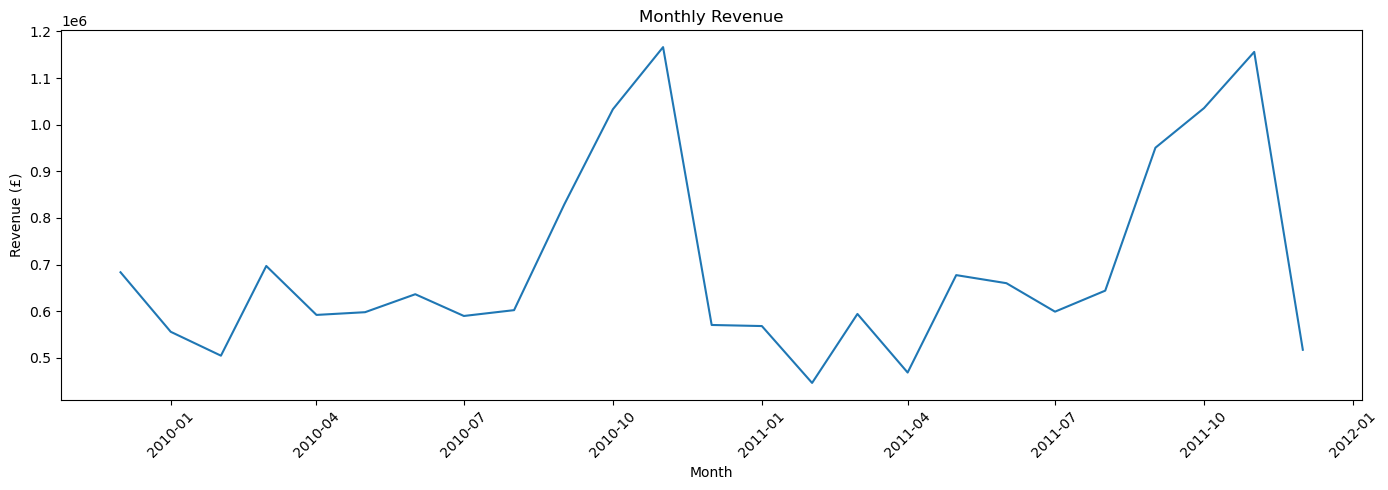

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["month"],
    monthly_sales["revenue"]
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Part F — Top customers
query = """
SELECT
    "Customer ID" AS customer_id,
    COUNT(DISTINCT Invoice) AS invoices,
    COUNT(DISTINCT StockCode) AS products,
    SUM(Quantity) AS quantity,
    SUM(Revenue) AS revenue
FROM customer_sales
GROUP BY "Customer ID"
ORDER BY revenue DESC
LIMIT 20
"""

top_customers = con.sql(query).df()

top_customers

,customer_id,invoices,products,quantity,revenue
0,18102,145,382,"181,645.00","580,987.04"
1,14646,151,961,"367,193.00","528,602.52"
2,14156,156,1446,"164,325.00","313,437.62"
3,14911,398,2550,"147,972.00","291,420.81"
4,17450,51,144,"83,914.00","244,784.25"
5,13694,143,896,"188,201.00","195,640.69"
6,17511,60,657,"117,174.00","172,132.87"
7,16446,2,3,"80,997.00","168,472.50"
8,16684,55,184,"104,810.00","147,142.77"
9,12415,28,498,"91,447.00","144,458.37"


In [16]:
# Part G — Revenue concentration
customer_revenue = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

customer_revenue["cumulative_revenue"] = (
    customer_revenue["Revenue"].cumsum()
)

customer_revenue["cumulative_percentage"] = (
    customer_revenue["cumulative_revenue"]
    / customer_revenue["Revenue"].sum()
    * 100
)

In [17]:
customers_for_80 = (
    customer_revenue["cumulative_percentage"] <= 80
).sum()

print("Customers generating first 80% of revenue:", customers_for_80)

print(
    "Percentage of customers:",
    customers_for_80 / len(customer_revenue) * 100
)

Customers generating first 80% of revenue: 1353
Percentage of customers: 23.01803334467506


In [18]:
# Part H — Product performance
query = """
SELECT
    StockCode,
    MAX(Description) AS description,
    COUNT(DISTINCT Invoice) AS invoices,
    SUM(Quantity) AS units_sold,
    SUM(Revenue) AS revenue
FROM customer_sales
GROUP BY StockCode
ORDER BY revenue DESC
LIMIT 20
"""

top_products = con.sql(query).df()

top_products

,StockCode,description,invoices,units_sold,revenue
0,22423,REGENCY CAKESTAND 3 TIER,3317,"24,124.00","277,656.25"
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,4895,"91,814.00","247,203.36"
2,23843,"PAPER CRAFT , LITTLE BIRDIE",1,"80,995.00","168,469.60"
3,85099B,RED RETROSPOT JUMBO BAG,3260,"93,436.00","167,920.64"
4,M,Manual,620,"9,384.00","151,777.67"
5,POST,POSTAGE,1803,"5,235.00","124,648.04"
6,84879,ASSORTED COLOUR BIRD ORNAMENT,2652,"78,234.00","124,351.86"
7,47566,PARTY BUNTING,2077,"23,460.00","103,283.38"
8,23166,MEDIUM CERAMIC TOP STORAGE JAR,195,"77,916.00","81,416.73"
9,22086,PAPER CHAIN KIT 50'S CHRISTMAS,1691,"28,380.00","76,598.18"


In [19]:
# Part I — Average Order Value
query = """
SELECT
    SUM(Revenue) / COUNT(DISTINCT Invoice) AS average_order_value
FROM customer_sales
"""

con.sql(query)

┌─────────────────────┐
│ average_order_value │
│       double        │
├─────────────────────┤
│   469.9830741431608 │
└─────────────────────┘

In [20]:
# Part J — Orders per customer
query = """
SELECT
    "Customer ID" AS customer_id,
    COUNT(DISTINCT Invoice) AS orders
FROM customer_sales
GROUP BY "Customer ID"
ORDER BY orders DESC
"""

orders_per_customer = con.sql(query).df()

orders_per_customer.describe()

,customer_id,orders
count,"5,878.00","5,878.00"
mean,"15,315.31",6.29
std,"1,715.57",13.01
min,"12,346.00",1.00
25%,"13,833.25",1.00
50%,"15,314.50",3.00
75%,"16,797.75",7.00
max,"18,287.00",398.00


In [21]:
# Part K — Customer revenue distribution
query = """
SELECT
    "Customer ID" AS customer_id,
    COUNT(DISTINCT Invoice) AS orders,
    SUM(Revenue) AS revenue
FROM customer_sales
GROUP BY "Customer ID"
"""

customer_summary = con.sql(query).df()

customer_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,"5,878.00","15,315.31","1,715.57","12,346.00","13,833.25","15,314.50","16,797.75","18,287.00"
orders,"5,878.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
revenue,"5,878.00","2,955.90","14,440.85",2.95,342.28,867.74,"2,248.30","580,987.04"


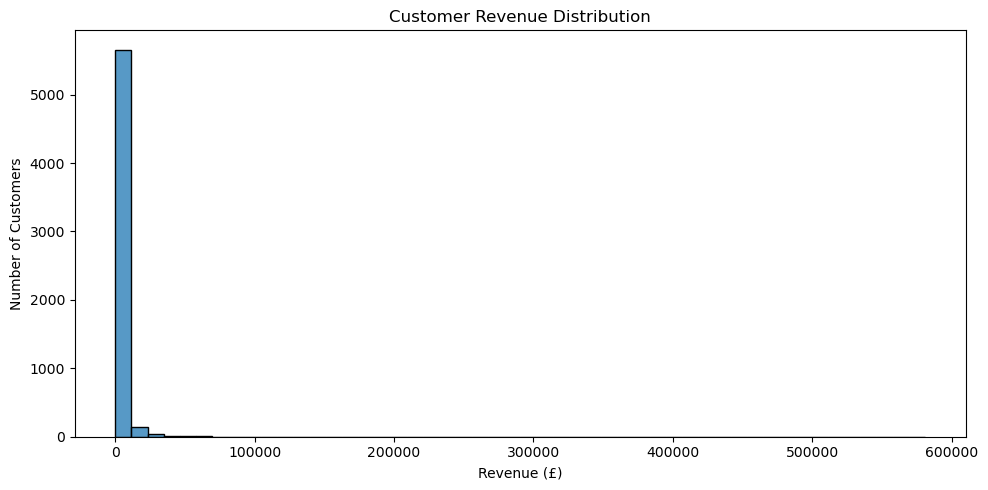

In [22]:
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_summary["revenue"],
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

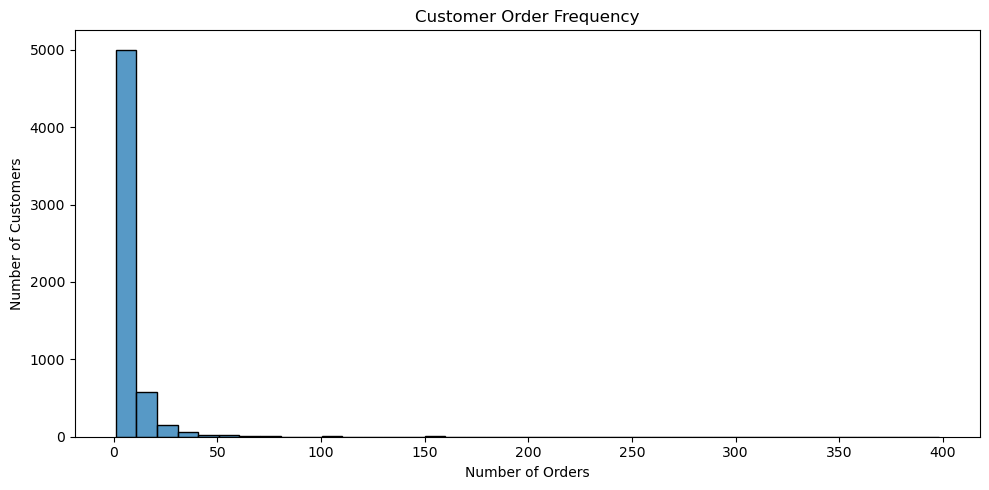

In [23]:
# Part L — Customer order frequency
plt.figure(figsize=(10, 5))

sns.histplot(
    customer_summary["orders"],
    bins=40
)

plt.title("Customer Order Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

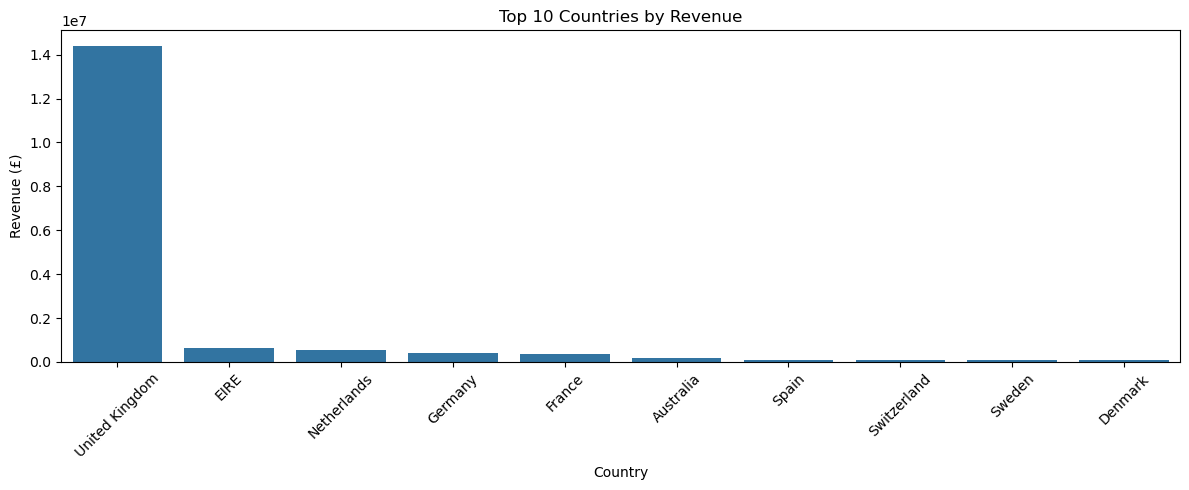

In [24]:
# Part M — Country revenue visualization
top_countries = country_analysis.head(10)

plt.figure(figsize=(12, 5))

sns.barplot(
    data=top_countries,
    x="Country",
    y="revenue"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# Part N — Customer revenue by country
query = """
SELECT
    Country,
    COUNT(DISTINCT "Customer ID") AS customers,
    SUM(Revenue) AS revenue,
    SUM(Revenue) / COUNT(DISTINCT "Customer ID") AS revenue_per_customer
FROM customer_sales
GROUP BY Country
HAVING COUNT(DISTINCT "Customer ID") >= 5
ORDER BY revenue_per_customer DESC
"""

country_value = con.sql(query).df()

country_value.head(15)

,Country,customers,revenue,revenue_per_customer
0,EIRE,5,"616,570.54","123,314.11"
1,Netherlands,22,"554,038.09","25,183.55"
2,Australia,15,"169,283.46","11,285.56"
3,Denmark,12,"68,580.69","5,715.06"
4,Sweden,19,"91,515.82","4,816.62"
5,Switzerland,22,"100,061.94","4,548.27"
6,Norway,13,"56,322.50","4,332.50"
7,Japan,10,"43,023.91","4,302.39"
8,Germany,107,"425,019.71","3,972.15"
9,Greece,5,"19,096.19","3,819.24"


In [32]:
# A. Return behavior
return_summary = (
    returns_df
    .groupby("Customer ID")
    .agg(
        return_lines=("Invoice", "size"),
        return_invoices=("Invoice", "nunique"),
        return_quantity=("Quantity", lambda x: x.abs().sum()),
        return_value=("ReturnValue", "sum")
    )
)

return_summary.describe().T

,count,mean,std,min,25%,50%,75%,max
return_lines,"2,572.00",7.15,16.14,1.00,1.00,3.00,7.00,365.00
return_invoices,"2,572.00",3.07,5.05,1.00,1.00,2.00,3.00,112.00
return_quantity,"2,572.00",183.89,"2,824.70",1.00,3.00,11.00,33.00,"87,923.00"
return_value,"2,572.00",421.78,"4,081.60",0.42,16.90,41.66,122.05,"168,478.60"


In [34]:
# Normalize identifier columns
returns_df["Invoice"] = returns_df["Invoice"].astype("string")
returns_df["StockCode"] = returns_df["StockCode"].astype("string")
returns_df["Description"] = returns_df["Description"].astype("string")
returns_df["Country"] = returns_df["Country"].astype("string")

In [35]:
returns_df["Customer ID"] = (
    returns_df["Customer ID"]
    .astype("Int64")
)

In [36]:
returns_df.dtypes

Invoice        string[python]
StockCode      string[python]
Description    string[python]
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID             Int64
Country        string[python]
LineTotal             float64
ReturnValue           float64
dtype: object

In [37]:
returns_df.to_parquet(
    RETURNS_PATH,
    index=False
)

print("Saved:", RETURNS_PATH)

Saved: C:\Users\arman\OneDrive\Desktop\Data_Analyst\Projects\CustomerIQ_Unsupervised\CustomerIQ\data\processed\customer_returns.parquet


In [38]:
print("Return rows:", len(returns_df))
print("Customers with returns:", returns_df["Customer ID"].nunique())
print("Total return value:", returns_df["ReturnValue"].sum())

Return rows: 22496
Customers with returns: 2572
Total return value: 1462424.1800000002


In [39]:
# 1. Non-merchandise transactions
non_merchandise_codes = [
    "POST",
    "M",
    "BANK CHARGES",
    "D",
    "C2",
    "CRUK",
    "DOT"
]

df[
    df["StockCode"].isin(non_merchandise_codes)
].groupby("StockCode").agg(
    description=("Description", "first"),
    invoices=("Invoice", "nunique"),
    quantity=("Quantity", "sum"),
    revenue=("Revenue", "sum")
).sort_values("revenue", ascending=False)

,description,invoices,quantity,revenue
StockCode,,,,
M,Manual,620,9384,"151,777.67"
POST,POSTAGE,1803,5235,"124,648.04"
C2,CARRIAGE,248,249,"12,546.00"
DOT,DOTCOM POSTAGE,16,16,"11,906.36"
BANK CHARGES,Bank Charges,30,31,450.00
D,Discount,5,196,397.89


In [40]:
df[
    df["StockCode"] == "23843"
][[
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "Price",
    "Customer ID",
    "Country",
    "Revenue"
]].sort_values(
    "Quantity",
    ascending=False
).head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country,Revenue
778958,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446,United Kingdom,"168,469.60"


In [41]:
df[
    df["StockCode"] == "23843"
].describe()

,Quantity,InvoiceDate,Price,Customer ID,LineTotal,Revenue
count,1.00,1,1.00,1.00,1.00,1.00
mean,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
min,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
25%,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
50%,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
75%,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
max,"80,995.00",2011-12-09 09:15:00,2.08,"16,446.00","168,469.60","168,469.60"
std,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
# Monthly revnue
monthly_sales

,month,invoices,customers,revenue
0,2009-12-01,1512,955,"683,504.01"
1,2010-01-01,1011,720,"555,802.67"
2,2010-02-01,1104,772,"504,558.96"
3,2010-03-01,1524,1057,"696,978.47"
4,2010-04-01,1329,942,"591,982.00"
5,2010-05-01,1377,966,"597,833.38"
6,2010-06-01,1497,1041,"636,371.13"
7,2010-07-01,1381,928,"589,736.17"
8,2010-08-01,1293,911,"602,224.60"
9,2010-09-01,1689,1145,"829,013.95"
